# VQC Based on IQC and IQC:AIL

## Imports

In [1]:
import qiskit
from qiskit_machine_learning.algorithms import VQC
from qiskit.circuit import QuantumCircuit
from qiskit.compiler import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram, visualize_transition, plot_bloch_vector
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Statevector,partial_trace, DensityMatrix

import pennylane
import qutip

import numpy as np
from scipy.linalg import expm as expMatrix
from sympy.physics.quantum.dagger import Dagger
import math

from sklearn.model_selection import StratifiedKFold,train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn import preprocessing
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, make_scorer, roc_auc_score

from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pdflatex

import pandas as pd


## Base de Dados

In [2]:
#Parâmetros
RANDOM_SEED = 42
LEARNING_RATE = 0.01
RESPONSE_METHOD = "predict"
results = []

In [3]:
#Gerando o dataset
path = "/Users/bito-/OneDrive - UFPE/Área de Trabalho/Bito/Exatas/MQ, CQ e IQ/TAAC1/Projeto-TAAC1/SSPE/Notif_Sindrome_Gripal_2024.csv"
sindrome = pd.read_csv(path,sep=';')
'''
Colunas do dataset:
"sintomas","profissionalSaude","racaCor","outrosSintomas","outrasCondicoes",
"profissionalSeguranca","cbo","condicoes","sexo",
"estado","estadoIBGE","municipio","municipioIBGE",
"origem","estadoNotificacao","municipioNotificacao","municipioNotificacaoIBGE",
"evolucaoCaso","classificacaoFinal","codigoEstrategiaCovid","codigoBuscaAtivaAssintomatico",
"outroBuscaAtivaAssintomatico","codigoTriagemPopulacaoEspecifica","outroTriagemPopulacaoEspecifica","codigoLocalRealizacaoTestagem",
"outroLocalRealizacaoTestagem","codigoRecebeuVacina","codigoLaboratorioPrimeiraDose",
"codigoLaboratorioSegundaDose","lotePrimeiraDose","loteSegundaDose","codigoContemComunidadeTradicional",
"source_id","excluido","validado","codigoDosesVacina",
"estadoNotificacaoIBGE","totalTestesRealizados","dataNotificacao","dataInicioSintomas",
"dataEncerramento","dataPrimeiraDose","dataSegundaDose","codigoEstadoTeste1",
"codigoTipoTeste1","codigoFabricanteTeste1","codigoResultadoTeste1","codigoEstadoTeste2",
"codigoTipoTeste2","codigoFabricanteTeste2","codigoResultadoTeste2","codigoEstadoTeste3",
"codigoTipoTeste3","codigoFabricanteTeste3","codigoResultadoTeste3","codigoEstadoTeste4",
"codigoTipoTeste4","codigoFabricanteTeste4","codigoResultadoTeste4","dataColetaTeste1",
"dataColetaTeste2","dataColetaTeste3","dataColetaTeste4","idade"'''

'''# data (as pandas dataframes) 
X_bc = bc.data.features 
X_bc = X_bc.values
y_bc = bc.data.targets
y_bc = y_bc.values'''


C:\Users\bito-\AppData\Local\Temp\ipykernel_5772\2086212676.py:3: DtypeWarning: Columns (12,62) have mixed types. Specify dtype option on import or set low_memory=False.
  sindrome = pd.read_csv(path,sep=';')


'# data (as pandas dataframes) \nX_bc = bc.data.features \nX_bc = X_bc.values\ny_bc = bc.data.targets\ny_bc = y_bc.values'

In [4]:
sindrome

,sintomas,profissionalSaude,racaCor,outrosSintomas,outrasCondicoes,profissionalSeguranca,cbo,condicoes,sexo,estado,...,codigoResultadoTeste3,codigoEstadoTeste4,codigoTipoTeste4,codigoFabricanteTeste4,codigoResultadoTeste4,dataColetaTeste1,dataColetaTeste2,dataColetaTeste3,dataColetaTeste4,idade
0,Assintomático,Não,Preta,NaN,NaN,Não,NaN,NaN,Masculino,Pernambuco,...,NaN,NaN,NaN,NaN,NaN,2022-02-08,NaN,NaN,NaN,30.0
1,"Coriza, Tosse, Febre, Dor de Garganta, Dor de ...",Não,Parda,NaN,NaN,Não,NaN,Imunossupressão,Feminino,Pernambuco,...,NaN,NaN,NaN,NaN,NaN,2021-12-18,NaN,NaN,NaN,NaN
2,Assintomático,Não,Ignorado,NaN,NaN,Não,NaN,NaN,Masculino,Pernambuco,...,NaN,NaN,NaN,NaN,NaN,2022-07-31,NaN,NaN,NaN,NaN
3,Tosse,Não,Branca,NaN,NaN,Não,NaN,NaN,Feminino,Pernambuco,...,NaN,NaN,NaN,NaN,NaN,2022-11-04,NaN,NaN,NaN,NaN
4,Assintomático,Não,Branca,NaN,NaN,Não,NaN,NaN,Masculino,Pernambuco,...,NaN,NaN,NaN,NaN,NaN,2022-08-15,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284446,"Coriza, Dor de Cabeça, Tosse, Febre",Não,Branca,NaN,NaN,Não,NaN,NaN,Masculino,Pernambuco,...,NaN,NaN,NaN,NaN,NaN,2024-01-16,NaN,NaN,NaN,NaN
284447,Assintomático,Não,Branca,NaN,NaN,Não,NaN,NaN,Feminino,Pernambuco,...,NaN,NaN,NaN,NaN,NaN,2024-01-02,NaN,NaN,NaN,NaN
284448,"Dor de Cabeça, Tosse, Febre",Não,Preta,NaN,NaN,Não,NaN,NaN,Masculino,Pernambuco,...,NaN,NaN,NaN,NaN,NaN,2024-01-16,NaN,NaN,NaN,31.0
284449,Assintomático,Não,Parda,NaN,NaN,Não,NaN,NaN,Feminino,Pernambuco,...,NaN,NaN,NaN,NaN,NaN,2024-01-03,NaN,NaN,NaN,NaN


In [5]:
sindrome.for

0         FIEtGYX0Z7
1         Fn7xgUphTG
2         GZCxB7uzFG
3         GuVaAxfBU1
4         BsFshcu2Xr
             ...    
284446    QFFsowQXrD
284447    QPK4O24Rzd
284448    RCLO03aH0B
284449    RpZOBVbtbj
284450    RqCuVYenQh
Name: source_id, Length: 284451, dtype: object

In [5]:
#Removendo as colunas que possuem valores nulos ou não existentes
sindrome.dropna(inplace=True, axis=1, how='any')
sindrome.drop('source_id', axis=1)

,sintomas,profissionalSaude,sexo,estado,municipio,origem,estadoNotificacao,excluido,validado,totalTestesRealizados,dataNotificacao
0,Assintomático,Não,Masculino,Pernambuco,Machados,parse-cloud,Pernambuco,False,False,1,2022-02-08
1,"Coriza, Tosse, Febre, Dor de Garganta, Dor de ...",Não,Feminino,Pernambuco,Recife,parse-cloud,Pernambuco,False,False,1,2021-12-18
2,Assintomático,Não,Masculino,Pernambuco,Moreno,parse-cloud,Pernambuco,False,False,1,2022-08-01
3,Tosse,Não,Feminino,Pernambuco,Recife,parse-cloud,Pernambuco,False,False,1,2022-11-04
4,Assintomático,Não,Masculino,Pernambuco,Recife,parse-cloud,Pernambuco,False,False,1,2022-08-15
...,...,...,...,...,...,...,...,...,...,...,...
284446,"Coriza, Dor de Cabeça, Tosse, Febre",Não,Masculino,Pernambuco,Limoeiro,parse-cloud,Pernambuco,False,False,1,2024-01-16
284447,Assintomático,Não,Feminino,Pernambuco,Caruaru,parse-cloud,Pernambuco,False,False,1,2024-01-02
284448,"Dor de Cabeça, Tosse, Febre",Não,Masculino,Pernambuco,Recife,parse-cloud,Pernambuco,False,False,1,2024-01-16
284449,Assintomático,Não,Feminino,Pernambuco,São Lourenço da Mata,parse-cloud,Pernambuco,False,False,1,2024-01-08


### Tratamento da Base de Dados

In [10]:
#Removendo as colunas que possuem valores nulos ou não existentes
sindrome.dropna(inplace=True, axis=1, how='any')
sindrome.drop('source_id', axis=1)

#Calcular a frequência absoluta de cada classe
frequencias = sindrome['municipio'].value_counts()

#Filtrar classes com frequência >= 2
classes_filtradas = frequencias[frequencias >= 2].index

sindrome = sindrome[sindrome['municipio'].isin(classes_filtradas)]


C:\Users\bito-\AppData\Local\Temp\ipykernel_12272\698429967.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sindrome.dropna(inplace=True, axis=1, how='any')


In [11]:
sindrome.municipio.value_counts()

municipio
Recife                     113931
Vitória de Santo Antão      15265
Petrolina                   10112
Caruaru                      9554
Cabo de Santo Agostinho      6360
                            ...  
Atibaia                         2
Capivari                        2
Suzano                          2
Trairi                          2
Congo                           2
Name: count, Length: 457, dtype: int64

In [12]:
for col in sindrome.columns:
    if col != 'municipio':
        sindrome[col] = sindrome[col].astype('category').cat.codes

In [13]:
sindrome

,sintomas,profissionalSaude,sexo,estado,municipio,origem,estadoNotificacao,source_id,excluido,validado,totalTestesRealizados,dataNotificacao
0,0,0,2,16,Machados,1,0,73837,0,0,0,514
1,707,0,0,16,Recife,1,0,76578,0,0,0,462
2,0,0,2,16,Moreno,1,0,80979,0,0,0,688
3,1731,0,0,16,Recife,1,0,82827,0,0,0,783
4,0,0,2,16,Recife,1,0,54759,0,0,0,702
...,...,...,...,...,...,...,...,...,...,...,...,...
284446,509,0,2,16,Limoeiro,1,0,125574,0,0,0,1221
284447,0,0,0,16,Caruaru,1,0,126332,0,0,0,1207
284448,1436,0,2,16,Recife,1,0,129768,0,0,0,1221
284449,0,0,0,16,São Lourenço da Mata,1,0,132567,0,0,0,1213


In [7]:
sindrome_train, sindrome_test = train_test_split(sindrome, test_size=0.3, random_state=RANDOM_SEED, stratify=sindrome['municipio'])

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [4]:
#Gerando os datasets de treino e teste
bc_train,bc_test=train_test_split(bc.data.original,test_size=0.3,train_size=0.7)

lista=[]
for i in range(len(X_bc[0])):
    lista.append(i)

X_train = bc_train.iloc[:,lista]
X_train = X_train.values
y_train = bc_train.iloc[:,31]
y_train = y_train.values

X_test = bc_test.iloc[:,lista]
X_test = X_test.values
y_test = bc_test.iloc[:,31]
y_test = y_test.values


In [29]:
N_FEATURES = len(X_bc[0])
N_SAMPLES = len(X_bc)
N_PRINTINGS = N_SAMPLES//10

## Quantum Circuit

Não geraremos imagens ainda

X[20]: [np.float64(13.08), np.float64(15.71), np.float64(85.63), np.float64(520.0), np.float64(0.1075), np.float64(0.127), np.float64(0.04568), np.float64(0.0311), np.float64(0.1967), np.float64(0.06811), np.float64(0.1852), np.float64(0.7477), np.float64(1.383), np.float64(14.67), np.float64(0.004097), np.float64(0.01898), np.float64(0.01698), np.float64(0.00649), np.float64(0.01678), np.float64(0.002425), np.float64(14.5), np.float64(20.49), np.float64(96.09), np.float64(630.5), np.float64(0.1312), np.float64(0.2776), np.float64(0.189), np.float64(0.07283), np.float64(0.3184), np.float64(0.08183), 0, 0] ; w: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0] 

sigmaE
[[1.308e+01 0.000e+00 0.000e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 1.571e+01 0.000e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 8.563e+01 ... 0.000e+00 0.000e+00 0.000e+00]
 ...
 [0.000e+00 0.000e+00 0.000e+00 ... 8.183e-02 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 ..

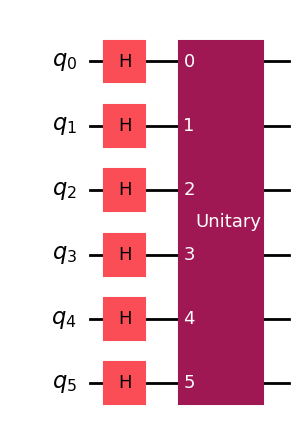

In [6]:
# Criando o circuito com um vetor qualquer do dataset para exemplificar

N_atributos=N_FEATURES 
'''
Numero de atributos do vetor a ser classificado. Adicionamos mais 1 ao numero obtido antes(pois temos o qubit alvo)
'''
#Escolhendo uma linha aleatória de X para podermos debugar
rd=[i for i in range(len(X_bc))]
j=int(np.random.choice(lista))

w=np.full(N_atributos,1)

#x=np.random.rand(N_atributos)
#w=np.random.rand(N_atributos)

N_qubits=math.ceil(np.log2(N_atributos)+1) #Nqubits do circuito

#Podíamos inicializar assim pra facilitar as contas
'''x=np.random.rand(2**N_atributos)
w=np.random.rand(2**N_atributos)'''

# IQC

qc = QuantumCircuit(N_qubits)
qc.h(0) # Inicializaçao do estado inicial. Poderia ser qualquer estado.
qc.h(range(1,N_qubits))



#Montando os sigmas

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z



X_bc_new=list(X_bc[j])
if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
    for k in range(2**(N_qubits-1) - N_atributos):
        X_bc_new.append(0)
        w=np.append(w,0)
    sigmaE=np.diag(X_bc_new)*w.T
else:
    sigmaE=np.diag(X_bc_new)*w.T

#Debugando
print(f'X[{j}]:', X_bc_new, '; w:', w,'\n')
print('sigmaE')
print(sigmaE)
#Operador Unitário
U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

qubits=[i for i in range(N_qubits)]
# qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
qc.unitary(U,qubits)
qc.draw("mpl")

In [7]:
#Decompondo em portas U3 e CX
qc = transpile(qc, optimization_level=3, basis_gates=["u3", "cx"])
print(dict(qc.count_ops()))
if dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['u3']<=50:
    display(qc.draw('mpl'))

{'u3': 1490, 'cx': 978}


### Statevector e Matriz Densidade

Aqui vamos avaliar o estado depois da evolução 

#### Statevector

<IPython.core.display.Latex object>

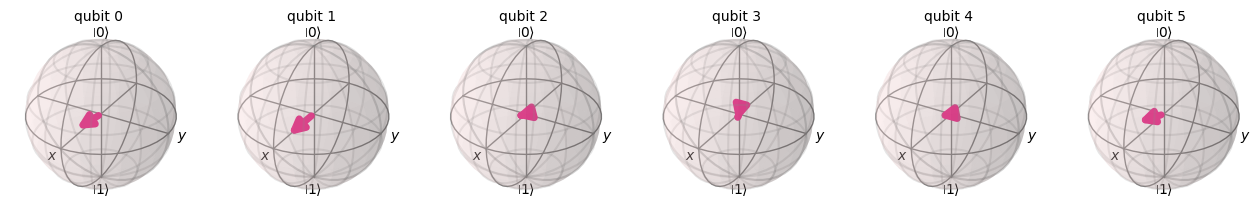

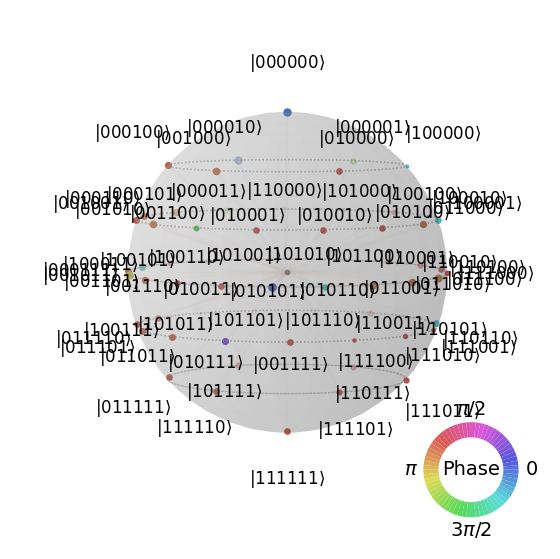

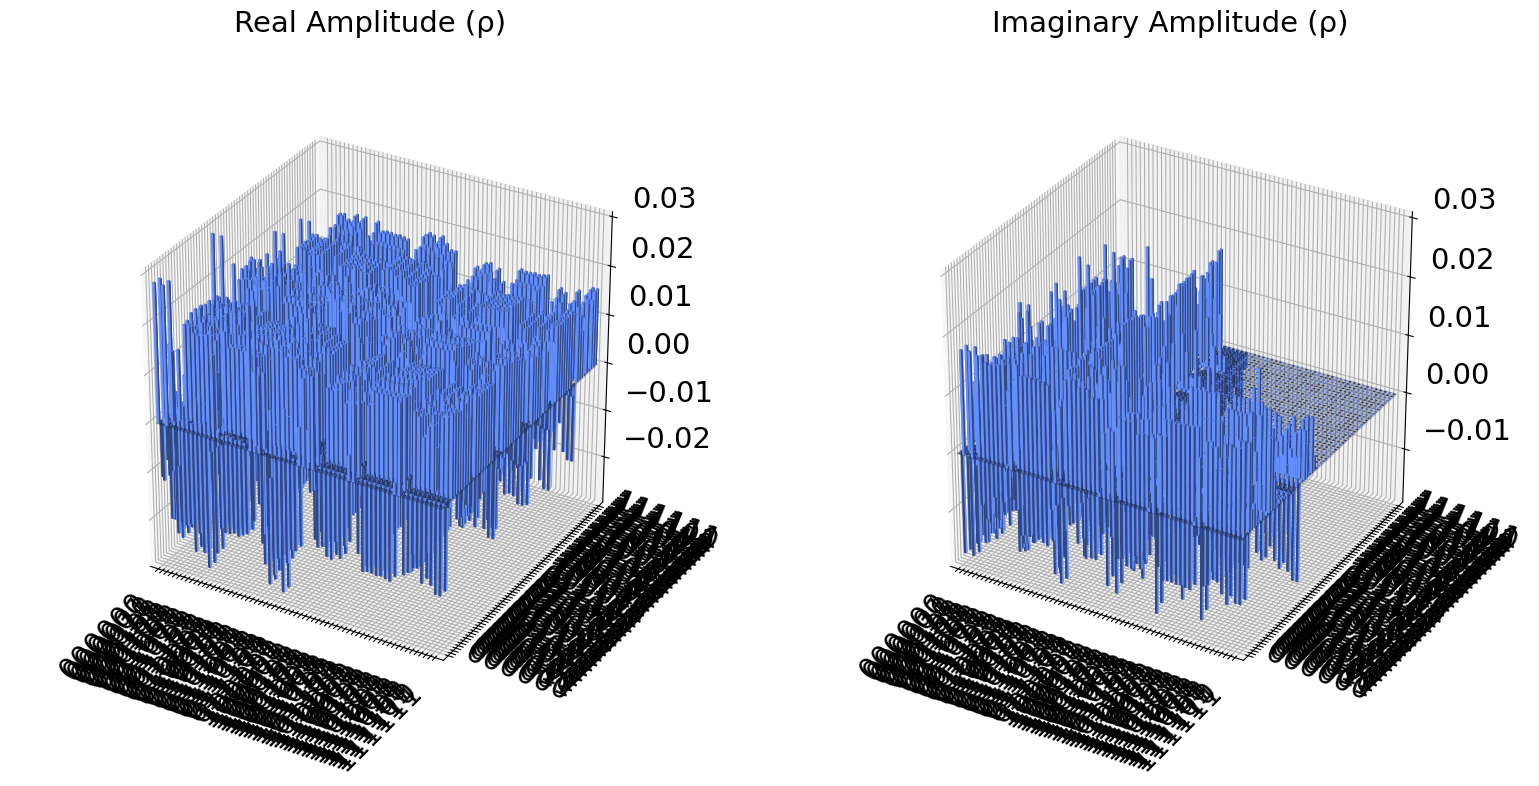

In [8]:
#Estado completo
sv = Statevector(qc)
'''
'mpl' is not a valid option for drawing Statevector objects. Please choose from:
            'text', 'latex', 'latex_source', 'qsphere', 'hinton',
            'bloch', 'city' or 'paulivec'
'''

display(sv.draw("latex")) #Plota o vetor de estado já em cada espaço de Hilbert
display(sv.draw("bloch")) #Plota o vetor de estado já em cada espaço de Hilbert
display(sv.draw("qsphere")) #Plota o vetor de estado em uma esfera que mapeia o espaço tensorial originado pelos espaços de Hilbert
display(sv.draw("city")) #Plota o histograma da matriz densidade SEM MEDÍ-LA


#### Partial Trace

Vamos traçar o sis. auxiliar

In [9]:
rho = partial_trace(sv,qubits[1:])
print(rho)

def blochvector(rho):
    x = np.trace(matriz_pauli_x@rho.data)
    y= np.trace(matriz_pauli_y@rho.data)
    z = np.trace(matriz_pauli_z@rho.data)
    return [x,y,z]
blochvector(rho)


DensityMatrix([[0.5       -1.42339398e-19j, 0.27085596+4.49617745e-02j],
               [0.27085596-4.49617745e-02j, 0.5       +1.41747784e-20j]],
              dims=(2,))


[np.complex128(0.5417119247790636+0j),
 np.complex128(-0.08992354903741251+0j),
 np.complex128(1.5543122344752192e-15-1.5651417627509312e-19j)]

#### Ponto na Casca da superfície da Esfera de Bloch

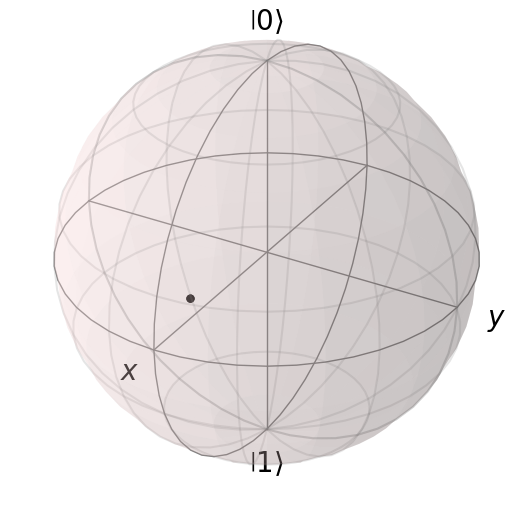

In [10]:
b = qutip.Bloch()
b.point_default_color=['k']
b.add_points(blochvector(rho))

b.render()
b.show()

#### Matriz Densidade

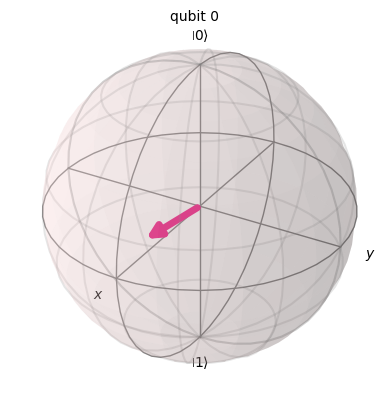

In [11]:
# Ao traçar fora o ambiente

rho_res = partial_trace(DensityMatrix.from_instruction(qc), qubits[1:])
#rho_res = partial_trace(DensityMatrix.from_instruction(qc), qubits[1:]).data

display(rho_res.draw('bloch'))


Como podemos observar, conseguimos marcar o ponto, na superfície da esfera, ao qual o autovetor do SISTEMA pertence. E se fizermos isso durante todo o código?

### Executando o Circuito

{'101011': 3, '000010': 38, '100010': 2, '001011': 34, '111110': 17, '010010': 20, '011011': 16, '001100': 10, '111101': 10, '100011': 26, '011001': 21, '110111': 22, '000000': 23, '011000': 16, '110010': 16, '000101': 28, '101110': 10, '000011': 18, '101100': 16, '110100': 14, '110000': 19, '000111': 20, '111010': 10, '100110': 10, '001111': 19, '011110': 17, '111100': 4, '100100': 17, '001101': 20, '110001': 11, '000110': 28, '101111': 21, '110011': 16, '000100': 16, '101101': 11, '100111': 15, '011101': 19, '010110': 20, '001010': 23, '100001': 19, '111111': 9, '010011': 15, '010000': 14, '011100': 25, '100000': 3, '010111': 19, '010100': 12, '010101': 32, '101010': 9, '110110': 14, '000001': 16, '001001': 14, '011111': 22, '011010': 22, '101001': 11, '001000': 25, '100101': 13, '111011': 11, '001110': 12, '101000': 7, '111001': 4, '111000': 8, '010001': 12}


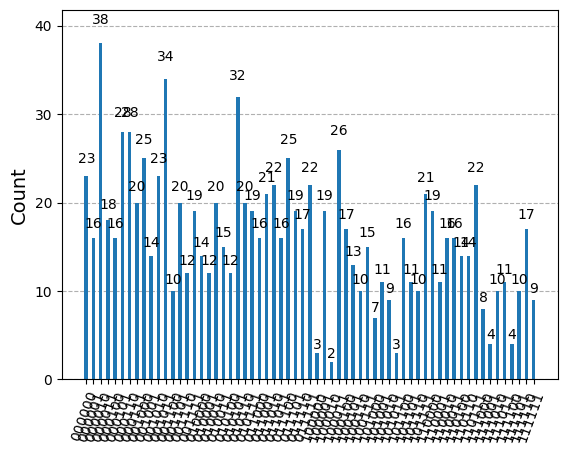

In [12]:
#Executar o circuito
def run_qasm_counts(circ, shots=1024):
  qc.measure_all()
  qasm_simulator = Aer.get_backend("qasm_simulator")
  job = qasm_simulator.run(qc, shots=shots)
  result = job.result()
  return result.get_counts()

counts = run_qasm_counts(qc)
print(counts)
plot_histogram(counts)

## Função que junta tudo até agora

In [18]:
def cirq(data,contador,N_atributos,printar_cirq=False):
    '''
    Numero de atributos do vetor a ser classificado. Adicionamos mais 1 ao numero obtido antes(pois temos o qubit alvo)
    '''
    w=np.full(N_atributos,1)
    

    #x=np.random.rand(N_atributos)
    #w=np.random.rand(N_atributos)

    N_qubits=math.ceil(np.log2(N_atributos)+1) #Nqubits do circuito

    #Podíamos inicializar assim pra facilitar as contas
    '''x=np.random.rand(2**N_atributos)
    w=np.random.rand(2**N_atributos)'''

    # IQC

    qc = QuantumCircuit(N_qubits)
    qc.h(0) # Inicializaçao do estado inicial. Poderia ser qualquer estado.
    qc.h(range(1,N_qubits))



    #Montando os sigmas

    matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
    matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
    matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

    sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

    X_bc_new=list(data)
    if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
        for k in range(2**(N_qubits-1) - N_atributos):
            X_bc_new.append(0)
            w=np.append(w,0)
        sigmaE=np.diag(X_bc_new)*w.T
    else:
        sigmaE=np.diag(X_bc_new)*w.T

    #Operador Unitário
    U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

    qubits=[i for i in range(N_qubits)]
    # qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
    qc.unitary(U,qubits)
    if contador%N_PRINTINGS==0:
        qc.draw("mpl", filename=f'./mpl_complete_U{contador}_bc.png')
    if printar_cirq==True:
        display(qc.draw('mpl')) #display(qc.draw("mpl", filename='./mpl_original.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    
    qc = transpile(qc, optimization_level=3, basis_gates=["u3", "cx"])
    if dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['u3']<=50 and contador%N_PRINTINGS==0:
        qc.draw("mpl", filename=f'./mpl_transpiled{contador}_bc.png')

    if printar_cirq==True and dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['u3']<=50:
        print(dict(qc.count_ops()))
        display(qc.draw('mpl')) #display(qc.draw('mpl', filename='./mpl_transpile.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    # Mostrando o vetor de estado 
    sv = Statevector(qc)
    if contador%N_PRINTINGS==0:
        sv.draw("city", filename=f'./state_vector_city{contador}_bc.png')
        sv.draw("bloch", filename=f'./state_vector_bloch{contador}_bc.png')
        sv.draw("qsphere", filename=f'./state_vector_qsphere{contador}_bc.png')
    if printar_cirq==True:
        display(sv.draw("latex"))

    rho = partial_trace(sv,qubits[1:])
    if printar_cirq==True:
        print(rho)

    def blochvector(rho):
        x = np.trace(matriz_pauli_x@rho.data)
        y= np.trace(matriz_pauli_y@rho.data)
        z = np.trace(matriz_pauli_z@rho.data)
        return [x,y,z]
    
    #Executar o circuito
    def run_qasm_counts(circ, shots=1024):
        qc.measure_all()
        qasm_simulator = Aer.get_backend("qasm_simulator")
        job = qasm_simulator.run(qc, shots=shots)
        result = job.result()
        return result.get_counts()

    counts = run_qasm_counts(qc)
    if contador%N_PRINTINGS==0:
        plot_histogram(counts,filename=f'./histogram_plot_{contador}_bc.png')
    
    

    return blochvector(rho)

## Esfera de Bloch do Circuito

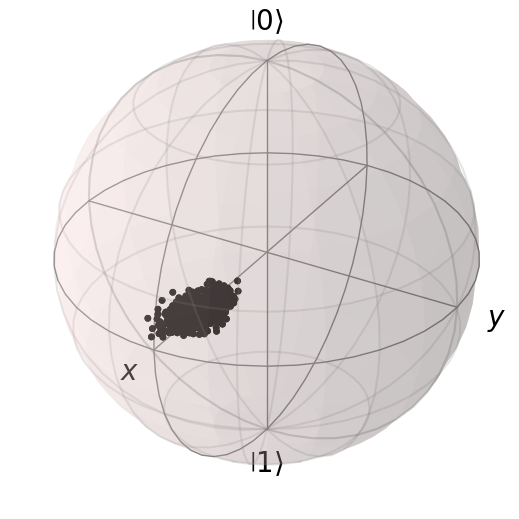

In [19]:
def esfera_bloch_CQ(X_bc,counter):
    point_states=[]
    for k in range(0,N_SAMPLES):
        point_states.append(cirq(X_bc[k],k,N_FEATURES))

    b = qutip.Bloch()
    b.point_default_color=['k']
    b.point_marker=['o']
    b.point_size=[15, 15, 15, 15]
    for k in range(len(point_states)):
        b.add_points(point_states[k])
    b.render()
    b.show()

    bb = b.fig
    bb.savefig(f'Bloch_geral_bc{counter}.png')

esfera_bloch_CQ(X_bc,1)

## IQC

In [3]:
def IQC(x,w):
  n = len(x)

  #from sympy.physics.matrices import msigma(indice)

  #Matrizes de Pauli e a matriz sigma-Q
  matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
  matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
  matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z



  sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

  sigmaE=np.diag(x)*w.T

  #Operador Unitário
  #Hint=- hbar*g*np.kron(sigmaQ,sigmaE)
  #U=expMatrix(-1j*Hint*(t/hbar))
  U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

  def get_p(psi):
    psi=np.matrix(psi)
    return psi*psi.getH()

  #Psis
  #Para os qubits
  psiQ=np.ones((2,1))
  psiQ=(psiQ/np.sqrt(2))

  psiE=np.ones((n,1))
  psiE=(psiE/np.sqrt(n))


  #Rhos
  rhoQ=get_p(psiQ)
  rhoE=get_p(psiE)
  rho_2_systems = np.array(U*(np.kron(rhoQ,rhoE))*Dagger(U))
  #p_cog_new = partial_trace(rho_2_systems, sys=2,dim=[2,n])
  rho_cog_new  = np.trace(rho_2_systems.reshape([2,n,2,n]), axis1=1, axis2=3)
  return rho_cog_new,sigmaE

## IQC:AIL

In [ ]:
def IQC_AIL(x,w):
  n = len(x)
  norma_x=np.linalg.norm(x)+1e-16 #To avoid zero division

  #Matrizes de Pauli e a matriz sigma-Q
  matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
  matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
  matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z



  sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

  sigmaE=np.diag(x)*w.T #No fim, é uma matriz composta apenas por pesos

  #Operador Unitário
  #Hint=- hbar*g*np.kron(sigmaQ,sigmaE)
  #U=expMatrix(-1j*Hint*(t/hbar))
  U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

  def get_p(psi):
    psi=np.matrix(psi)
    return psi*psi.getH()

  #Psis
  #Para os qubits
  psiQ=np.ones((2,1))
  psiQ=(psiQ/np.sqrt(2))

  psiE=np.ones((n,1))
  psiE=(psiE/np.sqrt(n))


  #Rhos
  rhoQ=get_p(psiQ)
  rhoE=get_p(psiE)
  rho_2_systems = np.array(U*(np.kron(rhoQ,rhoE))*Dagger(U))
  #p_cog_new = partial_trace(rho_2_systems, sys=2,dim=[2,n])
  rho_cog_new  = np.trace(rho_2_systems.reshape([2,n,2,n]), axis1=1, axis2=3)
  return rho_cog_new,sigmaE